In [1]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from DESolver import DESolver
from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE

import seaborn as sns
sns.set_context("talk", font_scale=1.) # "talk"

Solving Gray-Scott by using RK4


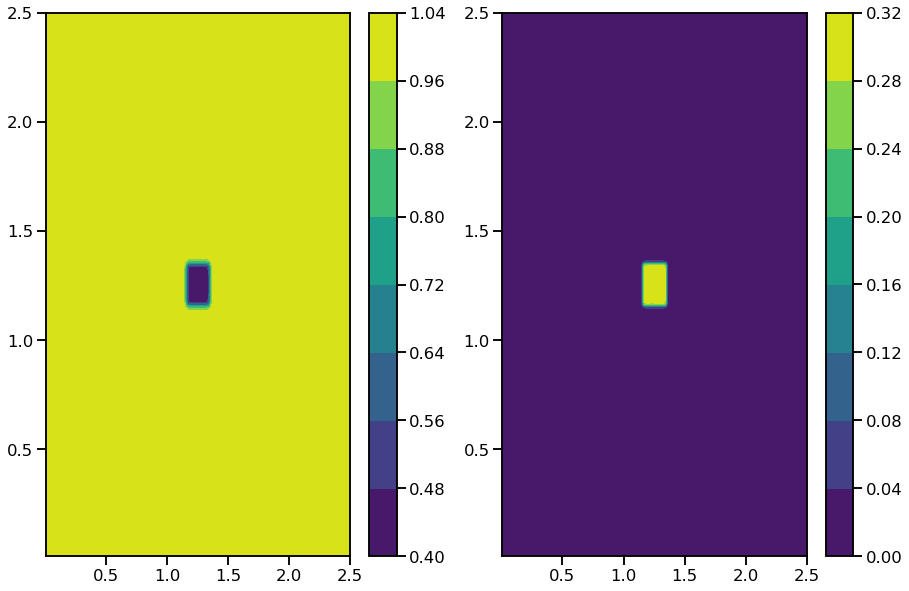

In [7]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup={'mx':256,'my':256,'n':2,
                   'x_min':0.,'x_max':2.5,'y_min':0.,'y_max':2.5,
                   'Du':2.0e-05,
                   'Dv':1.0e-05,
                   'kappa':0.054,
                   'Fuv':0.034}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Navier-Stokes2D',pde_problem_setup)#('Navier-Stokes2D')
solver.setup(keep_history=False)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)
solver.set_method('RK4')

if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()

u=solver.get_solution()

time_idx=-1
#sol=u[:,time_idx]
sol=u
unvec=problem_setup['context']['unvectorize']
y=unvec(sol,problem_setup['context'])

mx=problem_setup['context']['mx']
my=problem_setup['context']['my']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']
y_coord=problem_setup['context']['y_coord']
xv, yv = np.meshgrid(x_coord, y_coord)
fig = plt.figure(figsize=(15, 10))
plt.subplot(1,2,1)
plt.contourf(xv,yv,np.squeeze(y[0,:,:]))
plt.colorbar()
plt.subplot(1,2,2)
plt.contourf(xv,yv,np.squeeze(y[1,:,:]))
plt.colorbar()
plt.show()


In [3]:
problem_setup['T_DURATION']['start']

0.0

In [4]:
problem_setup['T_DURATION']['end']

5

In [5]:
problem_setup['DT']

1.0